In [1]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
import tensorflow as tf
from scipy.spatial.distance import pdist
from tensorflow import keras #type: ignore 
from keras import layers
from sklearn.preprocessing import StandardScaler
from arch import arch_model
import random
import optuna 
import logging
import datetime

DATA_FINAL = datetime.datetime.now().strftime('2026-04-07')
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --- Configuração inicial do modelo ---
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

CAPITAL_DISPONIVEL = 100000.0

# --- Carregamento e tratamento dos dados ---

tickers_dict = {
    'Tech': ['NVDA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'AVGO', 'TSM', 'TSLA'],
    'War': ['GE', 'RTX', 'BA', 'LMT', 'NOC', 'GD', 'AIR.PA', 'SAF.PA'],
    'Energy': [ 'XOM', 'CVX', 'SHEL', 'TTE', 'COP', 'BP', 'EQNR', 'ENB'],
    'Rare_earths': ['MP', 'LYC.AX', 'NB', 'UUUU', 'IPX', 'LAC'],
    'Precious_metals': ['GLD', 'SLV', 'IAU', 'PPLT', 'PALL'],
    'Currencies': ['EURUSD=X', 'GBPUSD=X', 'JPY=X', 'CHF=X', 'AUDUSD=X', 'NZDUSD=X', 'CAD=X']
}
all_tickers = [item for sublist in tickers_dict.values() for item in sublist]

raw_data = yf.download(all_tickers, start='2015-01-01', end=DATA_FINAL, auto_adjust=True)
close_df = raw_data['Close'].copy()
close_df.ffill()
close_df = close_df.dropna(how='all')

volume_df = raw_data['Volume'].copy() if 'Volume' in raw_data else pd.DataFrame(index=close_df.index, columns=close_df.columns)

valid_tickers = []
MIN_DAYS_HISTORY = 252
# Para a aplicação da forma correta e segura do HRP, exige-se pelo menos 1 ano útil.
# Sua utilização se deve, pois nem todas as empresas podem estar listadas desde o período inicial de dados. 
MIN_ADTV = 20_000_000

for t in all_tickers:
    if close_df[t].notna().sum() < MIN_DAYS_HISTORY:
        print(f'{t} rejeitado: Histórico de tempo muito curto')
        continue
    if not t.endswith('=X'):
        adtv_21 = (close_df[t].iloc[-21] * volume_df[t].iloc[-21]).mean()
        if pd.isna(adtv_21) or adtv_21 < MIN_ADTV:
            print(f'{t}: Baixa liquidez')
            continue
    valid_tickers.append(t)
clean_close = close_df[valid_tickers].copy()
clean_ret_log = np.log(clean_close / clean_close.shift(1))

#Winsorização Estocástica: Corta anomalias acima de 4 desvios padrões (Eventos de Cauda Longa)
for t in valid_tickers:
    media = clean_ret_log[t].mean()
    desvio = clean_ret_log[t].std()
    limite_superior = media + (4 * desvio)
    limite_inferior = media - (4 * desvio)

    clean_ret_log[t] = clean_ret_log[t].clip(lower=limite_inferior, upper=limite_superior)
print('Coleta e Análise de Dados do Portfólio Concluída')

[*********************100%***********************]  43 of 43 completed


IPX: Baixa liquidez
Coleta e Análise de Dados do Portfólio Concluída


In [2]:
# --- Aplicação do Modelo HRP (Marcos López de Prado) --- 
# Alocação de capital mitigando o risco sistêmico sem precisar inverter a matriz de covariância,
# evitando colapsos matemáticos quando os ativos são alteramente correlacionados. 

def get_quasi_diag(link):
    """""
    Reorganiza a matriz de covariância topologicamente. 
    Se Nvidia e AMD têm alta correlação, elas são movidas fisicamente para perto uma da outra na matriz, 
    formando um agrupamento lógico.
    """""
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >=num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index; j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df0])
        sort_ix = sort_ix.sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def get_cluster_var(cov, c_items):
    """""
     Dada uma submatriz (um nó da árvore), aloca peso internamente priorizando a menor variância: $w = \text{diag}(\Sigma)^{-0.5}$. 
     A variância final do cluster é calculada como $V = w^T \Sigma w$.
    """""
    cov_ = cov.iloc[c_items, c_items] 
    w_ = np.diag(cov_) ** -0.5
    w_ /= w_.sum()
    return np.dot(w_.T, np.dot(cov_, w_))

def get_rec_bipart(cov, sort_ix):
    """""
    O algoritmo corta a árvore hierárquica no meio repetidas vezes. 
    A cada bifurcação, o capital disponível é dividido entre o ramo esquerdo e o direito usando a fórmula
    $\alpha = 1 - \frac{V_0}{V_0 + V_1}$ ==> O Coração estatístico do modelo de HRP.
    """""
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]
            c_items1 = c_items[i + 1]
            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)
            alpha = 1 - c_var0 / (c_var0 + c_var1)
            w[c_items0] *= alpha
            w[c_items1] *= 1 - alpha
    return w


<>:27: SyntaxWarning: invalid escape sequence '\S'
<>:27: SyntaxWarning: invalid escape sequence '\S'
C:\Users\henri\AppData\Local\Temp\ipykernel_9676\2398277571.py:27: SyntaxWarning: invalid escape sequence '\S'
  Dada uma submatriz (um nó da árvore), aloca peso internamente priorizando a menor variância: $w = \text{diag}(\Sigma)^{-0.5}$.


In [3]:
# --- Configurações do modelo do E-Garch --- 
print("\nExtraindo Dados e Calibrando E-GARCH ")
egarch_volatility = pd.DataFrame()

# Usando valid_tickers e clean_ret_log do ETL
for t in valid_tickers: 
    try:
        # Multiplicamos por 100 para o modelo de convergência do ARCH funcionar melhor
        returns = 100 * clean_ret_log[t].dropna() 
        
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='t')
        res = am.fit(disp='off') 
        
        egarch_volatility[t] = res.conditional_volatility / 100
    except: continue

egarch_volatility = egarch_volatility.dropna()


Extraindo Dados e Calibrando E-GARCH 


In [4]:
print("Baixando dados OHLCV para os novos indicadores...")
# Precisamos de High, Low e Volume para o Estocástico e Volume Ratio
ohlcv = yf.download(valid_tickers, start='2015-01-01', end=DATA_FINAL, auto_adjust=True)

print("Baixando Leading Indicators Globais (VIX e Juros 10A)...")
macro_tickers = ['^VIX', '^TNX']
macro_data = yf.download(macro_tickers, start='2015-01-01', end=DATA_FINAL, auto_adjust=True)['Close']
macro_data = macro_data.ffill()
macro_data['VIX_Change'] = np.log(macro_data['^VIX'] / macro_data['^VIX'].shift(1)) 
macro_data['TNX_Change'] = macro_data['^TNX'].diff() 

panel = []
print("Construindo Painel Neural com Sistema de Pontuação...")

for t in valid_tickers:
    try: 
        if t not in egarch_volatility.columns: continue

        df = clean_close[[t]].copy()
        df.columns = ['Close']
        df = df.dropna()
        df['ticker'] = t

        # --- 1. DADOS EXTRAS PARA INDICADORES ---
        df['ret_log'] = clean_ret_log[t]
        df['High'] = ohlcv['High'][t]
        df['Low'] = ohlcv['Low'][t]
        df['Volume'] = ohlcv['Volume'][t]

        # --- 2. CÁLCULO DOS INDICADORES TÉCNICOS ---
        # RSI (14 days)
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-8)
        df['RSI'] = 100 - (100 / (1 + rs))

        # EMAs e MAs
        df['EMA_9'] = df['Close'].ewm(span=9, adjust=False).mean()
        df['EMA_21'] = df['Close'].ewm(span=21, adjust=False).mean()
        df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
        df['MA_50'] = df['Close'].rolling(window=50).mean()

        # MACD
        ema12 = df['Close'].ewm(span=12, adjust=False).mean()
        ema26 = df['Close'].ewm(span=26, adjust=False).mean()
        df['MACD'] = ema12 - ema26
        df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_hist'] = df['MACD'] - df['MACD_signal']

        # Volume Ratio e Momentum
        df['Volume_ratio'] = df['Volume'] / (df['Volume'].rolling(window=20).mean() + 1e-8)
        df['Price_momentum_1d'] = df['Close'].pct_change() # 24h momentum adaptado para diário

        # Estocástico (Stoch_K)
        low_14 = df['Low'].rolling(window=14).min()
        high_14 = df['High'].rolling(window=14).max()
        df['Stoch_K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14 + 1e-8))

        # --- 3. SISTEMA DE PONTOS (A SUGESTÃO DA ORTOGONALIZAÇÃO) ---
        df['points_buy'] = 0
        
        df.loc[df['RSI'] <= 30, 'points_buy'] += 20
        df.loc[(df['RSI'] > 30) & (df['RSI'] <= 40), 'points_buy'] += 10
        df.loc[df['RSI'] > 50, 'points_buy'] += 10
        
        ema_bullish = (df['EMA_9'] > df['EMA_50']) & (df['EMA_21'] > df['EMA_50'])
        df.loc[ema_bullish, 'points_buy'] += 15
        
        df.loc[df['MACD'] > 0, 'points_buy'] += 15
        
        macd_growing = df['MACD_hist'] > df['MACD_hist'].shift(1)
        df.loc[macd_growing, 'points_buy'] += 5
        
        df.loc[df['Volume_ratio'] >= 1.5, 'points_buy'] += 15
        df.loc[df['Price_momentum_1d'] > 0.02, 'points_buy'] += 5
        df.loc[df['Stoch_K'] <= 20, 'points_buy'] += 5

        # (Bandas de Bollinger foram removidas do modelo)

        # --- 4. TRIGGER DE VENDA SIMPLIFICADO ---
        ema9_above_ma50_prev = df['EMA_9'].shift(1) > df['MA_50'].shift(1)
        ema9_below_ma50_now = df['EMA_9'] <= df['MA_50']
        # Convertendo o booleano (True/False) para número (1/0) para a IA entender
        df['sell_trigger'] = (ema9_above_ma50_prev & ema9_below_ma50_now).astype(int) 

        # --- 5. RISCO E MACRO (Blindagem do Fundo) ---
        df['egarch_vol'] = egarch_volatility[t]
        df = df.join(macro_data[['VIX_Change', 'TNX_Change']], how='inner')

        # --- 6. TARGET MACHINE LEARNING ---
        df['target_weekly'] = np.log(df['Close'].shift(-5) / df['Close'].shift(-1))
        df['rank_score'] = df['target_weekly'] / (df['egarch_vol'] * np.sqrt(5) + 1e-6)
        
        panel.append(df)
    except Exception as e: 
        continue

data = pd.concat(panel).dropna()
data.index = data.index.tz_localize(None)
data['rank'] = data.groupby(data.index)['rank_score'].rank(pct=True)

# ---> O NOVO CÉREBRO DA IA <---
# A Inteligência Artificial agora cruza o seu Sistema de Pontos com a Macroeconomia!
features = ['points_buy', 'sell_trigger', 'egarch_vol', 'VIX_Change', 'TNX_Change']

# --- PREPARAÇÃO DE DADOS (Corte Cronológico TRAIN / VAL) ---
train_data = data[data.index < '2026-01-01']
val_data = data[(data.index >= '2026-01-01') & (data.index < data.index.max())]

scaler = StandardScaler()
X_train = scaler.fit_transform(train_data[features])
y_train = train_data['rank'].values
X_val = scaler.transform(val_data[features])
y_train = (train_data['rank_score'] > 0).astype(int).values
y_val = (val_data['rank_score'] > 0).astype(int).values

[*****                 10%                       ]  4 of 42 completed

Baixando dados OHLCV para os novos indicadores...


[*********************100%***********************]  42 of 42 completed


Baixando Leading Indicators Globais (VIX e Juros 10A)...


[*********************100%***********************]  2 of 2 completed


Construindo Painel Neural com Sistema de Pontuação...


In [ ]:
# --- Optuna --- 
# O optuna vai otimizar toda a busca dos hiperparâmetros da rede neural, melhorando o desempenho do modelo. 

print("Iniciando Optuna: Buscando a Arquitetura Ideal da Rede neural")

# =========================================================================

def objective(trial):
    model = keras.Sequential()
    
    # 1. Camada Densa crua (sem ativação embutida)
    model.add(layers.Dense(trial.suggest_int('units_1', 16, 64), input_dim=X_train.shape[1]))
    
    # 2. A MUDANÇA: LeakyReLU permite que a IA aprenda com sinais de mercado negativos
    model.add(layers.LeakyReLU(alpha=0.05))
    
    model.add(layers.Dropout(trial.suggest_float('drop_1', 0.2, 0.5)))
    
    # 3. Sigmoid na saída para cuspir Probabilidade (0 a 100%) #Evitar Shrinkage
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Binary Crossentropy para punir erros de direção (Classificação)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0, validation_split=0.1)
    
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    return val_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5) 

final_model = keras.Sequential([
    layers.Dense(study.best_params['units_1'], input_dim=X_train.shape[1]),
    layers.LeakyReLU(alpha=0.05), # Acompanha o modelo final
    layers.Dropout(study.best_params['drop_1']),
    layers.Dense(1, activation='sigmoid')
])
final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train, epochs=15, batch_size=64, verbose=0)

print(f"Melhor arquitetura encontrada: {study.best_params['units_1']} Neurônios com {study.best_params['drop_1']*100:.1f}% de Dropout.")

Iniciando Optuna: Buscando a Arquitetura Ideal da Rede neural


c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\henri\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Melhor arquitetura encontrada: 57 Neurônios com 36.4% de Dropout.


In [6]:
# --- Treinamento da Super Rede ---
print("\nTreinando a Super Rede com todos os dados disponíveis até hoje...")

X_all = np.vstack((X_train, X_val))
y_all = np.concatenate((y_train, y_val))

try:
    best_params = study.best_params
    print(f"Optuna funcionou. Usando: {best_params['units_1']} Neurônios.")
except Exception:
    print("⚠ Alerta: Optuna falhou nas tentativas. Acionando arquitetura padrão Institucional.")
    best_params = {'units_1': 32, 'drop_1': 0.3}

# Arquitetura com a correção do Input (Evita o UserWarning do Keras)
final_model = keras.Sequential([
    layers.Input(shape=(X_all.shape[1],)),
    layers.Dense(best_params['units_1']),
    layers.LeakyReLU(negative_slope=0.05), # negative_slope substitui alpha nas versões recentes
    layers.Dropout(best_params['drop_1']),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# CORREÇÃO CRÍTICA: Treinando com X_all e y_all em vez de X_train e y_train
final_model.fit(X_all, y_all, epochs=15, batch_size=64, verbose=0)

# Para avaliar, você pode checar no próprio X_all ou em um set de teste out-of-sample se houver
loss_final, acc_final = final_model.evaluate(X_all, y_all, verbose=0)
print(f"Acurácia Final no dataset completo: {acc_final*100:.2f}%")


Treinando a Super Rede com todos os dados disponíveis até hoje...
Optuna funcionou. Usando: 57 Neurônios.
Acurácia Final no dataset completo: 55.08%



-> Rodando Simulação de Monte Carlo (8.192 cenários) para o Risco da Próxima Semana...
Gerando Painel de Risco Monte Carlo para 42 ativos...


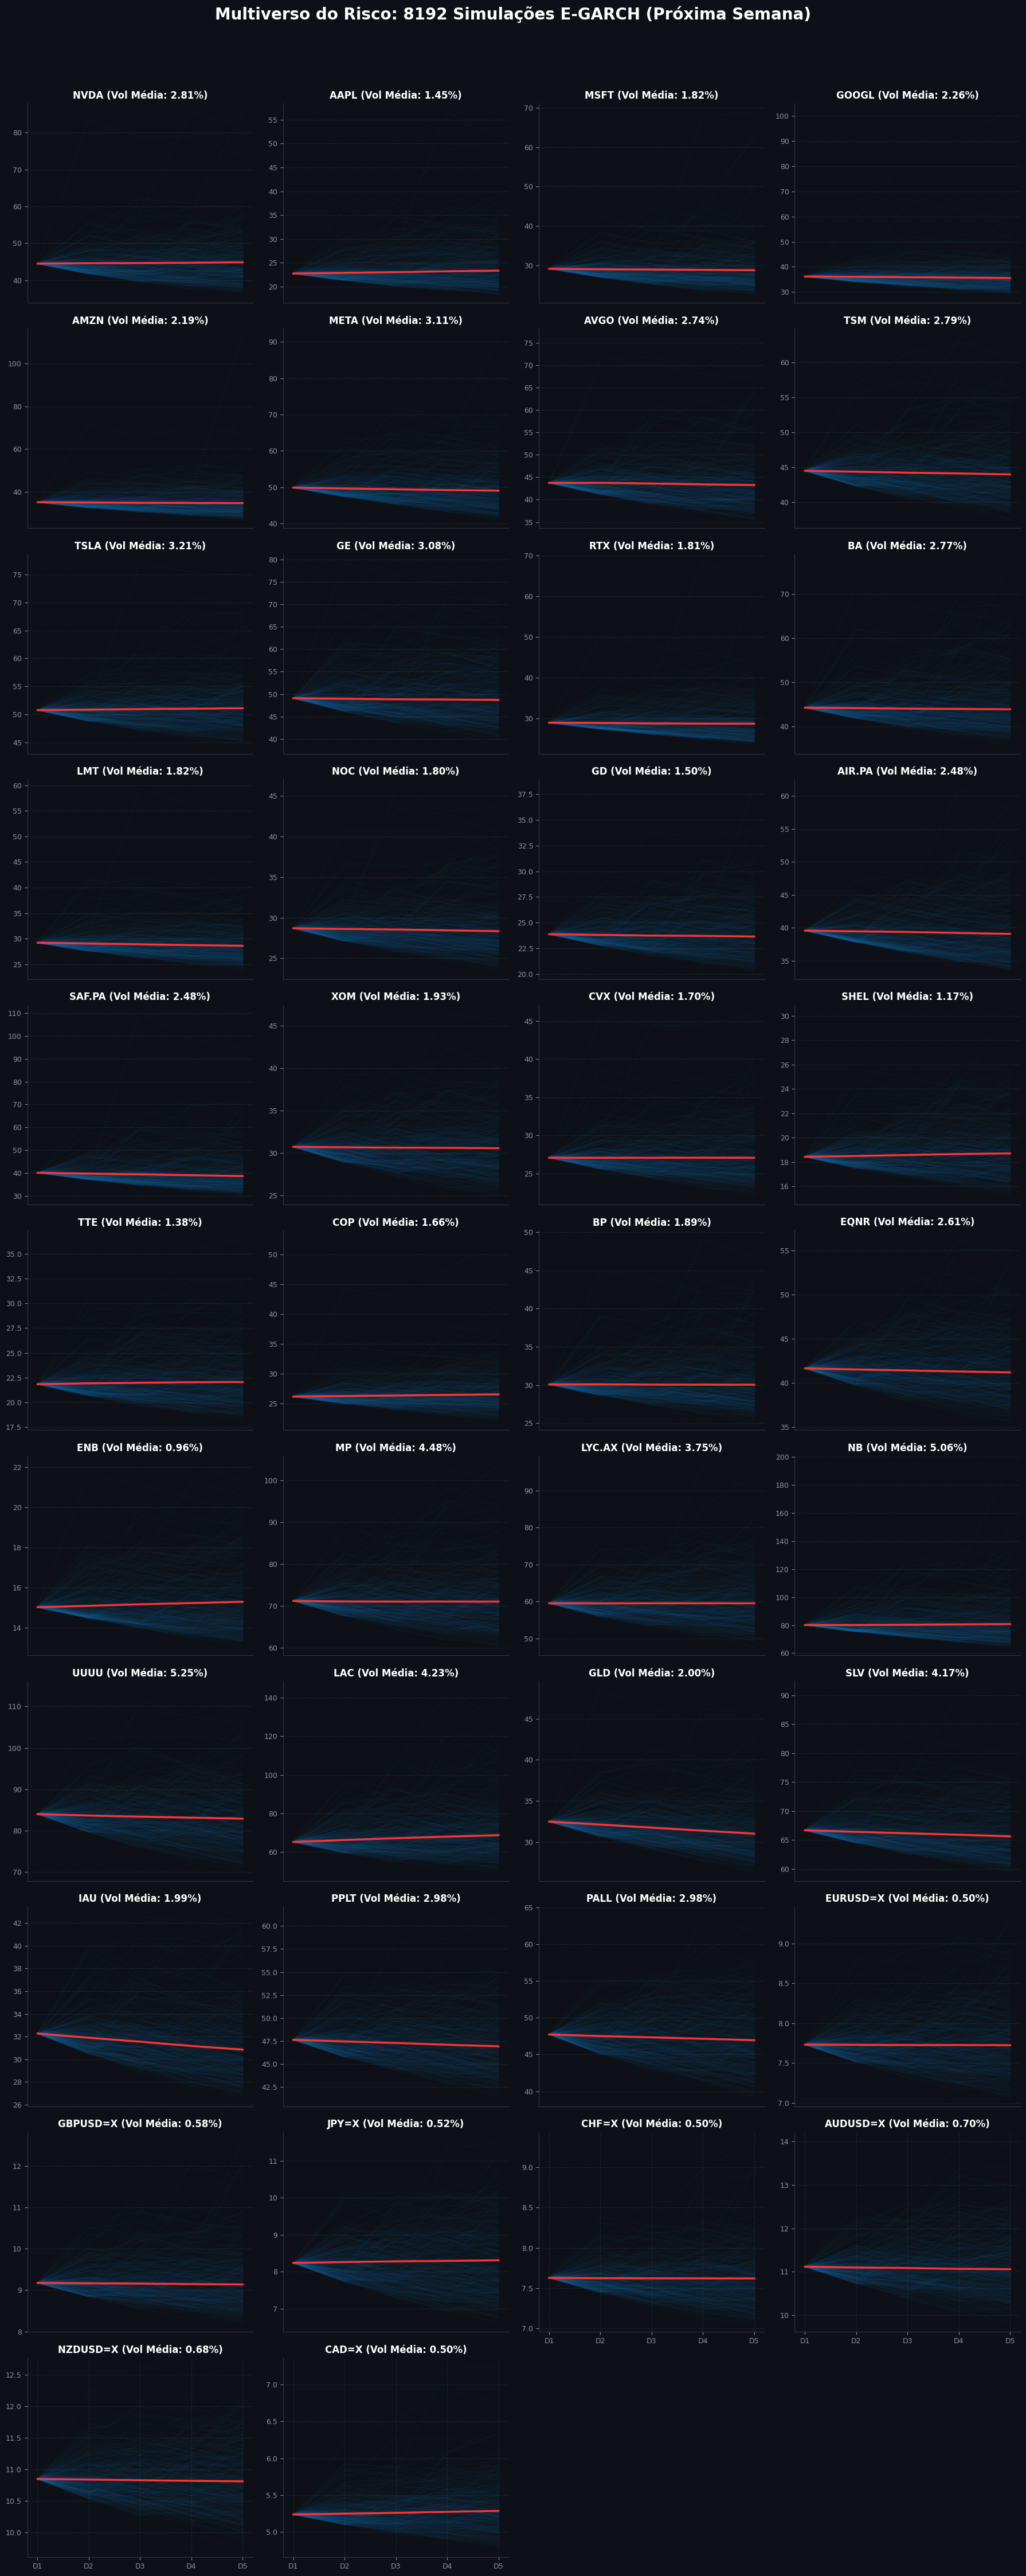

In [7]:
print("\n-> Rodando Simulação de Monte Carlo (8.192 cenários) para o Risco da Próxima Semana...")

horizon_time = 5 # Previsão para os 5 dias úteis da próxima semana
shots = 8192
mc_risk_dict = {}

# Dicionário para guardar os caminhos gerados para o Dashboard
mc_paths_plot = {} 

for t in valid_tickers:
    try:
        # Puxa os dados históricos limpos (do seu ETL) para aquele ativo
        returns = 100 * clean_ret_log[t].dropna()
        
        # Recalibra o E-GARCH rapidamente com os dados mais recentes
        am = arch_model(returns, vol='EGARCH', p=1, o=1, q=1, dist='t')
        res_egarch_fit = am.fit(disp='off')
        
        # A MÁGICA: Gera 4.096 futuros possíveis para a próxima semana
        forecast = res_egarch_fit.forecast(horizon=horizon_time, method='simulation', simulations=shots)
        
        # Extrai as variâncias simuladas (Última linha de dados projetada para o futuro)
        sim_variances = forecast.simulations.variances[-1, :, :]
        
        # Calcula a Volatilidade Diária Simulada (Raiz quadrada da variância)
        vol_paths = np.sqrt(sim_variances)
        
        # Métrica Institucional: Pegamos a MÉDIA de volatilidade dos 8.192 universos
        expected_vol = vol_paths.mean(axis=0).mean() # Média da semana
        
        # Guarda o risco simulado para o HRP usar (dividimos por 100 para voltar a percentual)
        mc_risk_dict[t] = expected_vol / 100 
        
        # Guarda os caminhos para plotar o cone de incerteza do ativo principal
        mc_paths_plot[t] = vol_paths * np.sqrt(252) # Anualiza para o gráfico
        
    except Exception as e:
        print(f"Erro no Monte Carlo para {t}: {e}")
        mc_risk_dict[t] = current_risk[t] # Fallback de segurança #type: ignore

# Atualiza a variável de risco que o HRP vai consumir!
current_risk_mc = pd.Series(mc_risk_dict).clip(lower=0.005)

#Plot das simulações de Monte Carlo
import math

# Pega todos os ativos que passaram com sucesso pelo Monte Carlo
ativos_plot = list(mc_paths_plot.keys())
n_ativos = len(ativos_plot)

# Configuração do Grid (ex: 4 colunas, número dinâmico de linhas)
colunas = 4
linhas = math.ceil(n_ativos / colunas)

# Prepara a "tela" do Dashboard (Dark Mode)
plt.style.use('dark_background')
fig, axes = plt.subplots(linhas, colunas, figsize=(18, 4 * linhas))
fig.patch.set_facecolor('#0d1117')

# Transforma a matriz de eixos em um array 1D para facilitar o loop
if n_ativos > 1:
    axes = axes.flatten()
else:
    axes = [axes] # Caso haja apenas 1 ativo

print(f"Gerando Painel de Risco Monte Carlo para {n_ativos} ativos...")

for i, t in enumerate(ativos_plot):
    ax = axes[i]
    ax.set_facecolor('#0d1117')
    
    # Extrai os 8.192 futuros possíveis
    vol_paths = mc_paths_plot[t] 
    
    # DOWNSAMPLING VISUAL: Sorteia 300 linhas para plotar a fumaça (Evita crash de RAM)
    max_linhas_plot = 300
    if vol_paths.shape[0] > max_linhas_plot:
        idx_sorteio = np.random.choice(vol_paths.shape[0], size=max_linhas_plot, replace=False)
        caminhos_fundo = vol_paths[idx_sorteio]
    else:
        caminhos_fundo = vol_paths
        
    # 1. Plota a "Nuvem" azul de incerteza (usando a amostra)
    ax.plot(caminhos_fundo.T, color='#1f77b4', alpha=0.03)
    
    # 2. Plota a Média Esperada (usando TODOS os 8.192 dados matemáticos originais)
    ax.plot(vol_paths.mean(axis=0), color='#ff3333', linewidth=2.5)
    
    # Formatação de cada mini-gráfico
    ax.set_title(f'{t} (Vol Média: {current_risk_mc[t]*100:.2f}%)', color='white', fontweight='bold')
    ax.tick_params(colors='#8b949e', labelsize=9)
    ax.grid(color='#30363d', linestyle='--', alpha=0.5)
    
    # Remove as bordas feias
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#30363d')
        
    # Coloca X labels apenas nos gráficos da última linha para ficar limpo
    if i >= n_ativos - colunas:
        ax.set_xticks(range(horizon_time))
        ax.set_xticklabels([f'D{j+1}' for j in range(horizon_time)])
    else:
        ax.set_xticks([])

# Limpa os "buracos" vazios do Grid (se o número de ativos não for múltiplo de 4)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Título Principal do Painel
fig.suptitle(f'Multiverso do Risco: {shots} Simulações E-GARCH (Próxima Semana)', 
             fontsize=20, color='white', fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#O risco para o Monte Carlo completo é 

In [8]:
# --- Inferência: Forecast para a próxima semana ---
from scipy.stats import norm

print("\nRodando Forecast (Filtro de Kalman + HRP com Cópulas) para a próxima semana...")

latest_date = data.index.max()
latest_data = data.groupby('ticker').tail(1).copy()

X_latest = scaler.transform(latest_data[features])

# =========================================================================
ia = []
for _ in range(10):
    chute = final_model(X_latest, training=True).numpy().flatten()
    ia.append(chute)

raw_preds = np.mean(ia, axis=0)

Q_noise, R_noise = 0.02, 0.10
smoothed_preds = []

for z in raw_preds:
    x_prior, P_prior = 0.5, 1.0 + Q_noise
    K = P_prior / (P_prior + R_noise)
    x_post = x_prior + K * (z - x_prior)
    smoothed_preds.append(x_post)

latest_data['pred_score'] = smoothed_preds

# === Aplicando o Fitro === 

limiar = latest_data['pred_score'].quantile(0.80)
candidates = latest_data[latest_data['pred_score'] > limiar]
selected_tickers = candidates['ticker'].tolist()

if len(selected_tickers) < 2:
    print(f"\n=> ALERTA: Modelo indica Risco Extremo. Recomendação: Manter 100% em Caixa (R$ {CAPITAL_DISPONIVEL:.2f}).")
else:
    past_rets = data[(data.index <= latest_date) & (data.index >= latest_date - pd.Timedelta(days=180))]
    past_rets_pivot = past_rets.pivot_table(index=past_rets.index, columns='ticker', values='ret_log')
    
    # =====================================================================
    # --- MÓDULO DE CÓPULAS GAUSSIANAS (Substitui a Correlação Linear) ---
    # =====================================================================
    # 1. Transforma os retornos em Marginais Uniformes 
    uniform_marginals = past_rets_pivot[selected_tickers].rank(pct=True)
    
    # 2. Trava de Segurança: Evita limites absolutos 0 e 1 (infinito na CDF inversa)
    uniform_marginals = uniform_marginals.clip(lower=1e-4, upper=1-1e-4)
    
    # 3. Mapeamento para o Domínio Gaussiano (Inversa da CDF Normal: Z = Φ⁻¹(U))
    gaussian_marginals = pd.DataFrame(
        norm.ppf(uniform_marginals), 
        index=uniform_marginals.index, 
        columns=uniform_marginals.columns
    )
    
    # 4. Matriz de Dependência da Cópula (Muito mais robusta contra Cisnes Negros)
    copula_corr = gaussian_marginals.corr().fillna(0)
    # =====================================================================
    
    current_risk = candidates.set_index('ticker')['egarch_vol'].clip(lower=0.005)
    vol_diag = np.diag(current_risk.loc[selected_tickers].values)
    
    # Matriz Forward Looking agora usa a Cópula em vez da correlação de Pearson
    forward_cov = pd.DataFrame(
        np.dot(vol_diag, np.dot(copula_corr.values, vol_diag)), 
        index=selected_tickers, columns=selected_tickers
    )
    
    # A Distância Topológica baseada na Cópula
    dist = np.sqrt(0.5 * (1 - copula_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    
    sort_ix = get_quasi_diag(linkage)
    hrp_weights_raw = get_rec_bipart(forward_cov, sort_ix)
    
    weights = pd.Series(hrp_weights_raw.values, index=[selected_tickers[i] for i in hrp_weights_raw.index])
    
    # === 3. CONCENTRAÇÃO AGRESSIVA (Alinhado com o Backtest em 50%) ===
    weights = weights.clip(upper=0.50)
    weights /= weights.sum()
    
    print(f"\n=======================================================")
    print(f" Execução: PRÓXIMA SEMANA ")
    print(f"=======================================================")
    print(f"Capital Alocado: R$ {CAPITAL_DISPONIVEL:,.2f}\n")
    print(f"{'Ativo':<12} | {'Sinal IA':<10} | {'Risco GARCH':<12} | {'Alocação (%)':<15} | {'R$ Comprar'}")
    print("-" * 75)
    
    for t in selected_tickers:
        w = weights[t]
        sinal = candidates[candidates['ticker'] == t]['pred_score'].values[0]
        risco = current_risk[t] * 100 
        valor = w * CAPITAL_DISPONIVEL
        print(f"{t:<12} | {sinal:.4f}   | {risco:8.2f}%   | {w*100:10.2f}%    | R$ {valor:,.2f}")
    
    print("=======================================================")
    print("O Modelo usou Cópulas Gaussianas para mitigar falhas da correlação linear.")


Rodando Forecast (Filtro de Kalman + HRP com Cópulas) para a próxima semana...

 Execução: PRÓXIMA SEMANA 
Capital Alocado: R$ 100,000.00

Ativo        | Sinal IA   | Risco GARCH  | Alocação (%)    | R$ Comprar
---------------------------------------------------------------------------
MSFT         | 0.5610   |     2.00%   |      10.50%    | R$ 10,498.64
RTX          | 0.5622   |     1.91%   |       6.82%    | R$ 6,822.99
XOM          | 0.5621   |     1.53%   |       9.17%    | R$ 9,166.85
CVX          | 0.5659   |     1.23%   |      14.35%    | R$ 14,350.77
SHEL         | 0.5633   |     1.27%   |      13.22%    | R$ 13,216.61
TTE          | 0.5646   |     1.34%   |      11.89%    | R$ 11,887.40
COP          | 0.5646   |     1.51%   |      18.31%    | R$ 18,311.22
BP           | 0.5600   |     1.96%   |       7.77%    | R$ 7,766.54
IAU          | 0.5604   |     1.76%   |       7.98%    | R$ 7,978.99
O Modelo usou Cópulas Gaussianas para mitigar falhas da correlação linear.


In [9]:
# --- Análise de Confiança do Modelo ---
print("\n=======================================================")
print("Análise das Métricas de Confiança do Modelo")
print("=======================================================")

val_preds = final_model.predict(X_val, verbose=0).flatten()
eval_df = val_data.copy() #type:ignore 
eval_df['previsao_ia'] = val_preds

limiar_compra = eval_df['previsao_ia'].quantile(0.80) 
eval_df['sinal_compra'] = eval_df['previsao_ia'] > limiar_compra
eval_df['mercado_subiu'] = eval_df['target_weekly'] > 0

TP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == True)])
FP = len(eval_df[(eval_df['sinal_compra'] == True) & (eval_df['mercado_subiu'] == False)])
FN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == True)])
TN = len(eval_df[(eval_df['sinal_compra'] == False) & (eval_df['mercado_subiu'] == False)])

accuracy = (TP + TN) / len(eval_df) if len(eval_df) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
ic = eval_df['previsao_ia'].corr(eval_df['rank'], method='spearman')

print(f"-> Verdadeiros Positivos (TP) : {TP}")
print(f"-> Falsos Positivos (FP)      : {FP}")
print(f"-> Falsos Negativos (FN)      : {FN}")
print(f"-> Verdadeiros Negativos (TN) : {TN}")
print(f"ACCURACY  (Exatidão) : {accuracy:.2%}")
print(f"PRECISION (Precisão) : {precision:.2%}")
print(f"RECALL    (Revocação): {recall:.2%}")
print(f"F1 SCORE             : {f1_score:.4f}")
print(f"INFO. COEFFICIENT    : {ic:.4f}")
print("=======================================================")


Análise das Métricas de Confiança do Modelo
-> Verdadeiros Positivos (TP) : 255
-> Falsos Positivos (FP)      : 199
-> Falsos Negativos (FN)      : 928
-> Verdadeiros Negativos (TN) : 886
ACCURACY  (Exatidão) : 50.31%
PRECISION (Precisão) : 56.17%
RECALL    (Revocação): 21.56%
F1 SCORE             : 0.3115
INFO. COEFFICIENT    : 0.1123


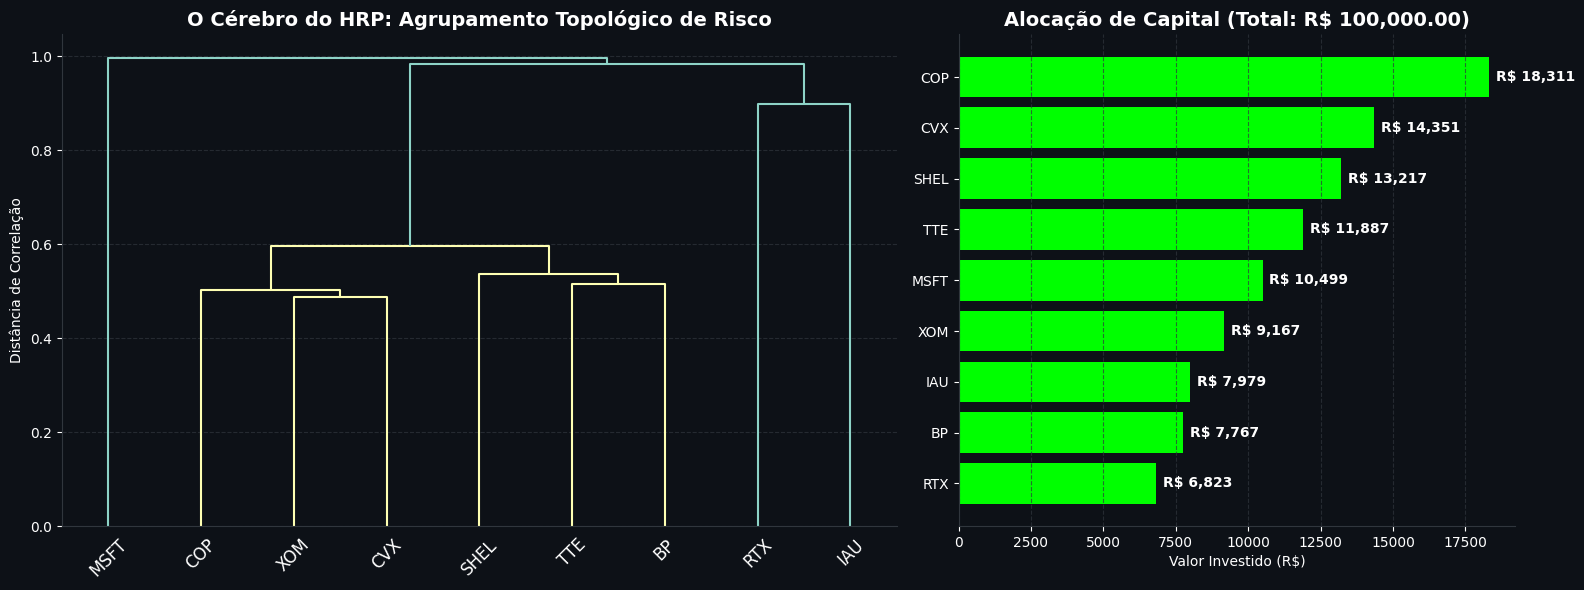

In [10]:
# --- Criação do Dashboard (Visualização Estética Bloomberg) ---
plt.style.use('dark_background')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.5, 1]})
fig.patch.set_facecolor('#0d1117')
ax1.set_facecolor('#0d1117')
ax2.set_facecolor('#0d1117')

sch.dendrogram(linkage, labels=selected_tickers, ax=ax1, leaf_rotation=45, leaf_font_size=12)
ax1.set_title("O Cérebro do HRP: Agrupamento Topológico de Risco", fontsize=14, fontweight='bold', color='white')
ax1.set_ylabel("Distância de Correlação", fontsize=10, color='white')
ax1.grid(axis='y', color='#30363d', linestyle='--', alpha=0.7)
ax1.tick_params(colors='white')

pesos_ordenados = weights.sort_values(ascending=True)
valores_financeiros = pesos_ordenados * CAPITAL_DISPONIVEL

bars = ax2.barh(pesos_ordenados.index, valores_financeiros.values, color='#00ff00', edgecolor='none')
ax2.set_title(f"Alocação de Capital (Total: R$ {CAPITAL_DISPONIVEL:,.2f})", fontsize=14, fontweight='bold', color='white')
ax2.set_xlabel("Valor Investido (R$)", fontsize=10, color='white')
ax2.grid(axis='x', color='#30363d', linestyle='--', alpha=0.7)
ax2.tick_params(colors='white')

for bar in bars:
    width = bar.get_width()
    ax2.annotate(f'R$ {width:,.0f}',
                 xy=(width, bar.get_y() + bar.get_height() / 2),
                 xytext=(5, 0),
                 textcoords="offset points",
                 ha='left', va='center', fontsize=10, color='white', fontweight='bold')
                 
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#30363d')
    ax.spines['bottom'].set_color('#30363d')

plt.tight_layout()
plt.show()

Iniciando Máquina do Tempo: Simulando alocação de R$ 100.000,00...

 RELATÓRIO DE PERFORMANCE: BACKTEST (Jan/2024 - Fev/2026)
Capital Inicial   : R$ 100,000.00
Capital Final     : R$ 106,976.50
-------------------------------------------------------
1. Lucro do Modelo: R$ 6,976.50 (6.98%)
2. Max Drawdown   : -15.23% (Pior queda sofrida)
3. Média Semanal  : 0.08% por semana
4. Mediana Semanal: 0.23% por semana


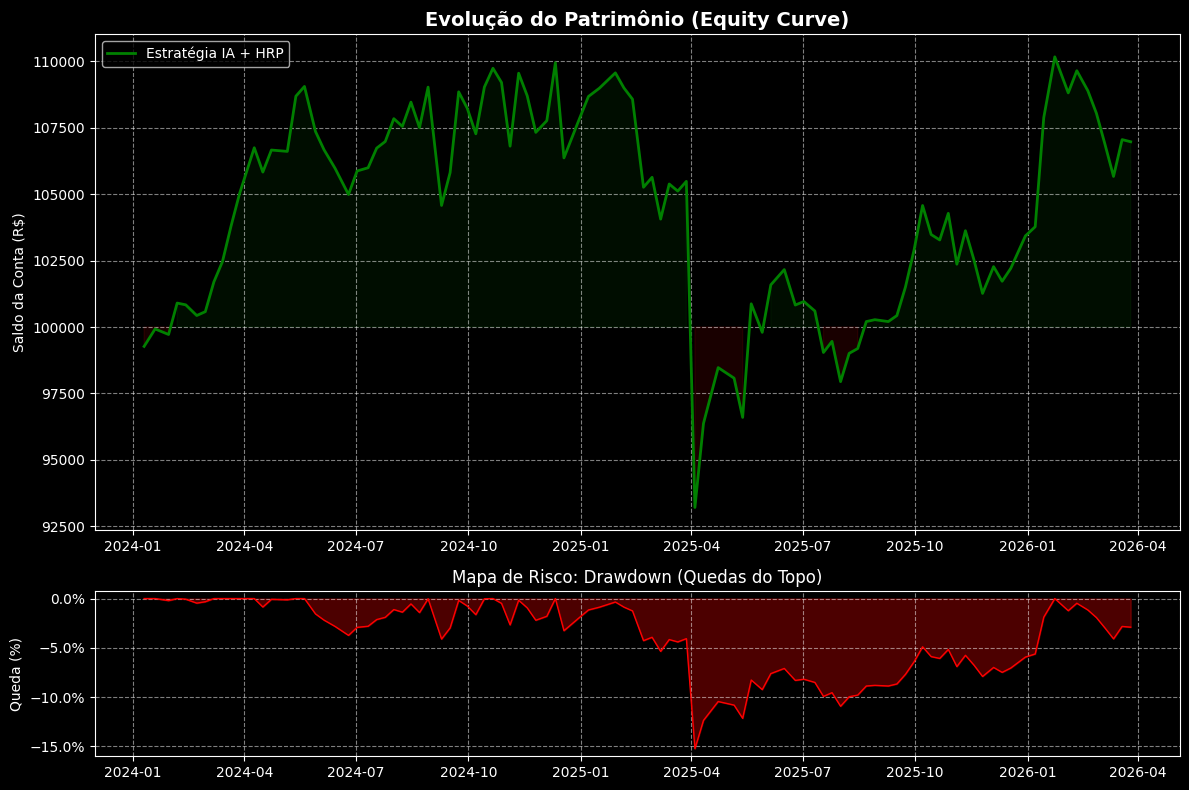

In [11]:
# Backtesting (2024-2026)

# =========================================================================
# --- MÓDULO DE BACKTEST: SIMULAÇÃO HISTÓRICA (2024 - 2026) ---
# =========================================================================
import matplotlib.ticker as mtick

print("Iniciando Máquina do Tempo: Simulando alocação de R$ 100.000,00...")

CAPITAL_INICIAL = 100000.0
DATA_INICIO = pd.to_datetime('2024-01-01')
DATA_FIM = pd.to_datetime(DATA_FINAL)

# Filtra os dados apenas para o período do teste
bt_data = data[(data.index >= DATA_INICIO) & (data.index <= DATA_FIM)].copy()

# Simula o rebalanceamento semanal (A cada 5 dias úteis de mercado)
unique_dates = np.sort(bt_data.index.unique())
rebalance_dates = unique_dates[::5] 

portfolio_history = []
current_capital = CAPITAL_INICIAL
pesos_anteriores = {} 
TAXA_CORRETAGEM = 0.001

# Loop no tempo: O robô acorda, lê os dados, investe, dorme por 5 dias e acorda de novo
for i in range(len(rebalance_dates) - 1):
    rebal_date = rebalance_dates[i]
    next_rebal_date = rebalance_dates[i+1]
    
    # 1. Fotografia do mercado no dia de hoje
    day_data = bt_data[bt_data.index == rebal_date].copy()
    if len(day_data) < 5: continue
    
    # Previsões
    X_day = scaler.transform(day_data[features])
    opinioes_ia = [final_model(X_day, training=True).numpy().flatten() for _ in range(10)]
    day_data['pred_score'] = np.mean(opinioes_ia, axis=0)
    
    # 3. Filtro de Elite (Top 15%)
    limiar = day_data['pred_score'].quantile(0.85)
    candidates = day_data[day_data['pred_score'] > limiar]
    selected_tickers = candidates['ticker'].tolist()
    
    taxa_livre_risco_semanal = 0.0020 
    
    if len(selected_tickers) < 1:
        # Robô sentiu perigo total: Fica 100% no CDI surfando os juros do Brasil
        turnover = sum(pesos_anteriores.values()) # Custo de vender tudo o que tínhamos na carteira
        custo_transacao_pct = turnover * TAXA_CORRETAGEM
        
        # O rendimento é o CDI menos o custo de zerar a posição
        retorno_liquido = taxa_livre_risco_semanal - custo_transacao_pct
        
        current_capital = current_capital * (1 + retorno_liquido)
        portfolio_history.append({'Date': next_rebal_date, 'Portfolio_Value': current_capital, 'Weekly_Return': retorno_liquido})
        
        pesos_anteriores = {} # Zeramos a memória da carteira (estamos em caixa)
        continue
        
    past_rets = data[(data.index <= rebal_date) & (data.index >= rebal_date - pd.Timedelta(days=180))]
    past_rets_pivot = past_rets.pivot_table(index=past_rets.index, columns='ticker', values='ret_log')
    sub_corr = past_rets_pivot[selected_tickers].corr().fillna(0)
    
    current_risk = candidates.set_index('ticker')['egarch_vol'].clip(lower=0.005)
    vol_diag = np.diag(current_risk.loc[selected_tickers].values)
    forward_cov = pd.DataFrame(np.dot(vol_diag, np.dot(sub_corr.values, vol_diag)), index=selected_tickers, columns=selected_tickers)
    
    dist = np.sqrt(0.5 * (1 - sub_corr))
    linkage = sch.linkage(pdist(dist), method='single')
    sort_ix = get_quasi_diag(linkage)
    hrp_weights_raw = get_rec_bipart(forward_cov, sort_ix)
    
    weights = pd.Series(hrp_weights_raw.values, index=[selected_tickers[idx] for idx in hrp_weights_raw.index])
    
    # === A MUDANÇA: CONCENTRAÇÃO AGRESSIVA (Até 50% em 1 ativo) ===
    weights = weights.clip(upper=0.50) 
    weights /= weights.sum()
    
    # 5. Apuração de Resultados
    pesos_novos = weights.to_dict()
    turnover = 0
    todos_ativos = set(pesos_anteriores.keys()).union(set(pesos_novos.keys()))
    
    for t in todos_ativos:
        peso_velho = pesos_anteriores.get(t, 0.0)
        peso_novo = pesos_novos.get(t, 0.0)
        # Mede a diferença exata do que precisou ser transacionado
        turnover += abs(peso_novo - peso_velho) 
        
    custo_transacao_pct = turnover * TAXA_CORRETAGEM
    
    # 5. Apuração de Resultados Brutos vs Líquidos
    port_return_bruto = 0
    for t in selected_tickers:
        w = weights[t]
        ret_ativo = day_data[day_data['ticker'] == t]['target_weekly'].values[0]
        port_return_bruto += w * ret_ativo
        
    # Desconta os custos da corretora do lucro da semana
    port_return_liquido = port_return_bruto - custo_transacao_pct
        
    current_capital = current_capital * (1 + port_return_liquido)
    portfolio_history.append({'Date': next_rebal_date, 'Portfolio_Value': current_capital, 'Weekly_Return': port_return_liquido})
    
    # Salva a carteira atual na memória para o cálculo da próxima semana
    pesos_anteriores = pesos_novos.copy()

# --- CÁLCULO DAS MÉTRICAS DE PERFORMANCE ---
bt_df = pd.DataFrame(portfolio_history).set_index('Date')

# Lucro Máximo (PnL Final)
capital_final = bt_df['Portfolio_Value'].iloc[-1]
lucro_total_rs = capital_final - CAPITAL_INICIAL
lucro_total_pct = (capital_final / CAPITAL_INICIAL) - 1

# Max Drawdown (O Teste Cardíaco)
# Calcula o maior pico histórico a cada dia
roll_max = bt_df['Portfolio_Value'].cummax()
# Calcula a queda percentual do preço atual em relação ao pico
drawdown = bt_df['Portfolio_Value'] / roll_max - 1.0
max_drawdown = drawdown.min()

# Média e Mediana
media_retorno = bt_df['Weekly_Return'].mean()
mediana_retorno = bt_df['Weekly_Return'].median()

# --- IMPRESSÃO DOS RESULTADOS ---
print("\n=======================================================")
print(" RELATÓRIO DE PERFORMANCE: BACKTEST (Jan/2024 - Fev/2026)")
print("=======================================================")
print(f"Capital Inicial   : R$ {CAPITAL_INICIAL:,.2f}")
print(f"Capital Final     : R$ {capital_final:,.2f}")
print("-" * 55)
print(f"1. Lucro do Modelo: R$ {lucro_total_rs:,.2f} ({lucro_total_pct:.2%})")
print(f"2. Max Drawdown   : {max_drawdown:.2%} (Pior queda sofrida)")
print(f"3. Média Semanal  : {media_retorno:.2%} por semana")
print(f"4. Mediana Semanal: {mediana_retorno:.2%} por semana")
print("=======================================================")

# --- PLOTAGEM DO GRÁFICO DA CURVA DE PATRIMÔNIO ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Gráfico de Crescimento do Capital
ax1.plot(bt_df.index, bt_df['Portfolio_Value'], color='green', linewidth=2, label='Estratégia IA + HRP')
ax1.fill_between(bt_df.index, bt_df['Portfolio_Value'], CAPITAL_INICIAL, where=(bt_df['Portfolio_Value'] > CAPITAL_INICIAL), color='green', alpha=0.1)
ax1.fill_between(bt_df.index, bt_df['Portfolio_Value'], CAPITAL_INICIAL, where=(bt_df['Portfolio_Value'] <= CAPITAL_INICIAL), color='red', alpha=0.1)
ax1.set_title('Evolução do Patrimônio (Equity Curve)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Saldo da Conta (R$)')
ax1.grid(linestyle='--', alpha=0.5)
ax1.legend()

# Gráfico de Drawdown (Submerso)
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
ax2.plot(drawdown.index, drawdown, color='red', linewidth=1)
ax2.set_title('Mapa de Risco: Drawdown (Quedas do Topo)', fontsize=12)
ax2.set_ylabel('Queda (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

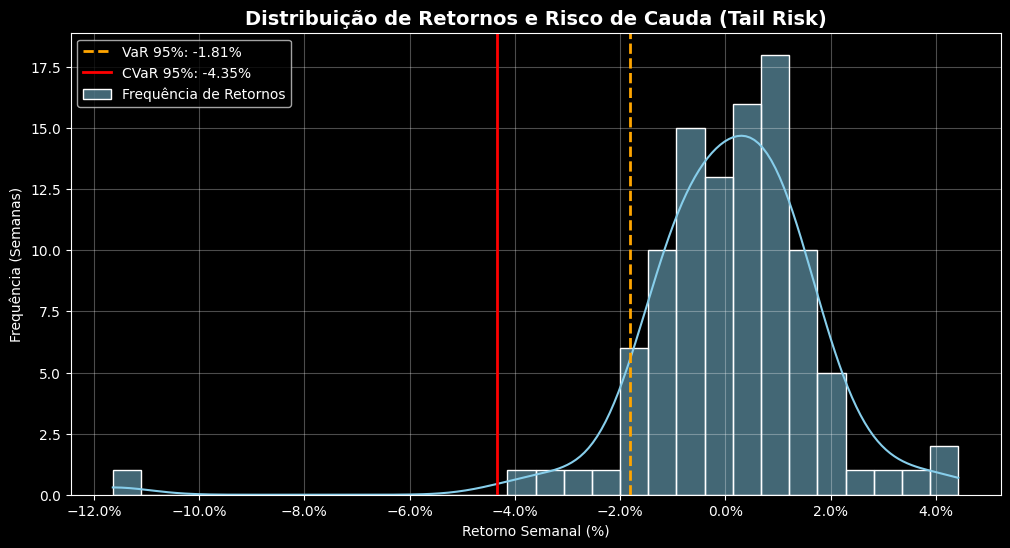

VaR 95% Semanal: -1.81%
CVaR 95% Semanal (Perda Média Extrema): -4.35%


In [12]:
# --- CÁLCULO DE VaR e CVaR (Nível de Confiança 95%) ---
import seaborn as sns 
confianca = 0.05  # 95% de confiança
retornos = bt_df['Weekly_Return']

# VaR: O limite da perda nas 5% piores semanas
var_95 = retornos.quantile(confianca)

# CVaR: A média das perdas que ultrapassaram o VaR (Expected Shortfall)
cvar_95 = retornos[retornos <= var_95].mean()

# --- PLOTAGEM DO GRÁFICO DE DISTRIBUIÇÃO DE RISCO ---
plt.figure(figsize=(12, 6))
sns.histplot(retornos, kde=True, color='skyblue', bins=30, label='Frequência de Retornos')

# Linhas de Risco
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'VaR 95%: {var_95:.2%}')
plt.axvline(cvar_95, color='red', linestyle='-', linewidth=2, label=f'CVaR 95%: {cvar_95:.2%}')

# Estilização Faria Lima
plt.title('Distribuição de Retornos e Risco de Cauda (Tail Risk)', fontsize=14, fontweight='bold')
plt.xlabel('Retorno Semanal (%)')
plt.ylabel('Frequência (Semanas)')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"VaR 95% Semanal: {var_95:.2%}")
print(f"CVaR 95% Semanal (Perda Média Extrema): {cvar_95:.2%}")

Calculando Métricas de Risco de Cauda (Tail Risk)...


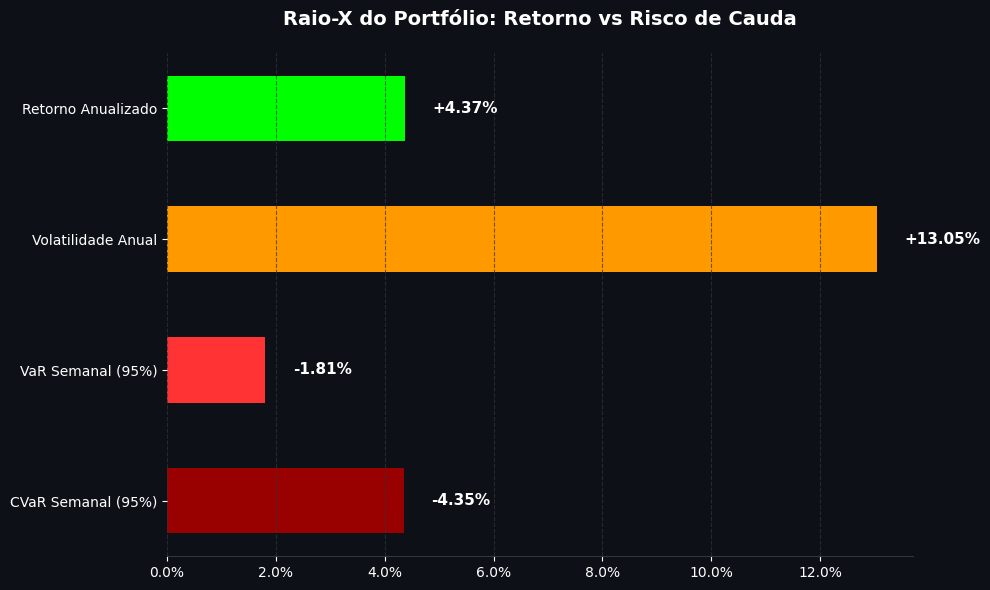


--- SUMÁRIO DE RISCO ---
Retorno Esperado (Ano): +4.37%
Volatilidade (Ano)    :  13.05%
VaR 95% (Semanal)     : -1.81% (Em 95% das semanas, não perderemos mais que isso)
CVaR 95% (Semanal)    : -4.35% (Nas piores 5% das semanas, esta é a perda média)


In [13]:
print("Calculando Métricas de Risco de Cauda (Tail Risk)...")

# 1. Extração dos retornos da simulação
rets = bt_df['Weekly_Return'].dropna()

# 2. Cálculos Institucionais (Anualizando Retorno e Volatilidade)
# Como rebalanceamos a cada 5 dias (1 semana), usamos fator 52 para anualizar
retorno_anualizado = ((1 + rets.mean()) ** 52) - 1
volatilidade_anualizada = rets.std() * np.sqrt(52)

# 3. Cálculo do VaR e CVaR (Confiança de 95% na janela semanal)
# O VaR é o percentil 5% dos piores retornos.
var_95 = np.percentile(rets, 5)

# O CVaR (Expected Shortfall) é a média de todos os retornos piores que o VaR
cvar_95 = rets[rets <= var_95].mean()

# =========================================================================
# --- PLOTAGEM DO DASHBOARD DE RISCO ---
# =========================================================================
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Nomes e Valores (Transformando VaR e CVaR em números absolutos positivos para visualização)
metricas = ['Retorno Anualizado', 'Volatilidade Anual', 'VaR Semanal (95%)', 'CVaR Semanal (95%)']
valores = [retorno_anualizado, volatilidade_anualizada, abs(var_95), abs(cvar_95)]

# Cores: Verde para Retorno, Laranja para Vol, Vermelho para VaR, Vinho para CVaR
cores = ['#00ff00', '#ff9900', '#ff3333', '#990000']

# Criando as barras horizontais
bars = ax.barh(metricas, valores, color=cores, height=0.5, edgecolor='none')

# Estilização
ax.set_title('Raio-X do Portfólio: Retorno vs Risco de Cauda', fontsize=14, fontweight='bold', color='white', pad=20)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis='x', color='#30363d', linestyle='--', alpha=0.7)
ax.invert_yaxis()  # Para o Retorno ficar no topo

# Adicionando os valores em texto na ponta de cada barra
for bar, valor in zip(bars, valores):
    # Se for VaR ou CVaR, colocamos o sinal de negativo de volta no texto
    texto = f"-{valor:.2%}" if valor in [abs(var_95), abs(cvar_95)] else f"+{valor:.2%}"
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
            texto, va='center', ha='left', color='white', fontweight='bold', fontsize=11)

# Limpeza de bordas
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#30363d')

plt.tight_layout()
plt.show()

# Imprime o sumário no terminal
print("\n--- SUMÁRIO DE RISCO ---")
print(f"Retorno Esperado (Ano): +{retorno_anualizado:.2%}")
print(f"Volatilidade (Ano)    :  {volatilidade_anualizada:.2%}")
print(f"VaR 95% (Semanal)     : {var_95:.2%} (Em 95% das semanas, não perderemos mais que isso)")
print(f"CVaR 95% (Semanal)    : {cvar_95:.2%} (Nas piores 5% das semanas, esta é a perda média)")

In [14]:
# --- ANÁLISE AVANÇADA: Dinâmica de Correlações e Regimes ---

# 1. Correlação Exponencialmente Ponderada (Peso maior para dados recentes)
from sklearn.preprocessing import StandardScaler

def ewma_correlation(returns, span=252):
    """Calcula correlação exponencialmente ponderada"""
    cov_ewma = returns.ewm(span=span, adjust=False).cov()
    std_ewma = returns.ewm(span=span, adjust=False).std()
    
    corr_ewma = pd.DataFrame(
        index=returns.columns,
        columns=returns.columns,
        data=np.eye(len(returns.columns))
    )
    
    for i, col1 in enumerate(returns.columns):
        for j, col2 in enumerate(returns.columns):
            if i != j:
                corr_ewma.loc[col1, col2] = (
                    cov_ewma.loc[(col1, col2)] / (std_ewma.iloc[-1, i] * std_ewma.iloc[-1, j])
                )
    return corr_ewma

print("\n" + "="*80)
print("ANÁLISE DINÂMICA E DE REGIMES DE CORRELAÇÃO")
print("="*80)

# 2. Quebra temporal: Correlações em diferentes períodos
periods = {
    'Recente (últimos 252 dias)': clean_ret_log.iloc[-252:],
    'Intermediário (252-504 dias)': clean_ret_log.iloc[-504:-252],
    'Histórico (504-756 dias)': clean_ret_log.iloc[-756:-504] if len(clean_ret_log) > 756 else None
}

period_analysis = {}
print("\n" + "-"*80)
print("CORRELAÇÃO MÉDIA POR PERÍODO")
print("-"*80)

for period_name, period_data in periods.items():
    if period_data is not None and len(period_data) > 10:
        period_corr_matrix = period_data.corr()
        period_mean_corr = period_corr_matrix.values[np.triu_indices_from(period_corr_matrix.values, k=1)].mean()
        period_analysis[period_name] = {
            'mean': period_mean_corr,
            'std': period_corr_matrix.values[np.triu_indices_from(period_corr_matrix.values, k=1)].std(),
            'min': period_corr_matrix.values[np.triu_indices_from(period_corr_matrix.values, k=1)].min(),
            'max': period_corr_matrix.values[np.triu_indices_from(period_corr_matrix.values, k=1)].max()
        }
        print(f"\n{period_name}:")
        print(f"  Média: {period_analysis[period_name]['mean']:.4f}")
        print(f"  Desvio Padrão: {period_analysis[period_name]['std']:.4f}")
        print(f"  Intervalo: [{period_analysis[period_name]['min']:.4f}, {period_analysis[period_name]['max']:.4f}]")

# 3. Detecção de Regimes: Alta vs Baixa Volatilidade
portfolio_volatility = clean_ret_log.std(axis=1).rolling(20).mean()
volatility_threshold = portfolio_volatility.median()
high_vol_periods = portfolio_volatility > portfolio_volatility.quantile(0.75)
low_vol_periods = portfolio_volatility < portfolio_volatility.quantile(0.25)

print("\n" + "-"*80)
print("ANÁLISE DE REGIMES: Correlação em Períodos de Volatilidade")
print("-"*80)

high_vol_data = clean_ret_log[high_vol_periods]
low_vol_data = clean_ret_log[low_vol_periods]

if len(high_vol_data) > 10:
    high_vol_corr = high_vol_data.corr()
    high_vol_mean = high_vol_corr.values[np.triu_indices_from(high_vol_corr.values, k=1)].mean()
    print(f"\nPeríodos de Alta Volatilidade ({len(high_vol_data)} dias):")
    print(f"  Correlação Média: {high_vol_mean:.4f}")

if len(low_vol_data) > 10:
    low_vol_corr = low_vol_data.corr()
    low_vol_mean = low_vol_corr.values[np.triu_indices_from(low_vol_corr.values, k=1)].mean()
    print(f"\nPeríodos de Baixa Volatilidade ({len(low_vol_data)} dias):")
    print(f"  Correlação Média: {low_vol_mean:.4f}")

if len(high_vol_data) > 10 and len(low_vol_data) > 10:
    correlation_increase = (high_vol_mean - low_vol_mean) / low_vol_mean * 100
    print(f"\nAumento de Correlação em Alta Volatilidade: {correlation_increase:+.2f}%")
    print(" Isso indica sincronização de risco durante crises!")

# 4. Estresse de Correlação: Comportamento de "Contagion"
print("\n" + "-"*80)
print("ANÁLISE DE CONTÁGIO (Contagion)")
print("-"*80)

# Identifica dias com retornos extremos
extreme_returns = (np.abs(clean_ret_log) > 2 * clean_ret_log.std()).sum(axis=1) > 3
extreme_dates = clean_ret_log[extreme_returns].index

if len(extreme_dates) > 0:
    print(f"\nDias com Movimentos Extremos Simultâneos: {len(extreme_dates)}")
    
    # Correlação durante dias extremos
    extreme_window_size = 20
    peak_contagion = 0
    peak_date = None
    
    for extreme_date in extreme_dates[:5]:  # Top 5 para análise
        idx = clean_ret_log.index.get_loc(extreme_date)
        if idx >= extreme_window_size:
            window_data = clean_ret_log.iloc[idx-extreme_window_size:idx]
            window_corr = window_data.corr()
            window_mean = window_corr.values[np.triu_indices_from(window_corr.values, k=1)].mean()
            if window_mean > peak_contagion:
                peak_contagion = window_mean
                peak_date = extreme_date
    
    print(f"Pico de Contágio (Correlação máxima em janela de estresse):")
    print(f"  Data: {peak_date}")
    print(f"  Correlação Média: {peak_contagion:.4f}")

# 5. Matriz de Correlação de Variação Temporal
print("\n" + "-"*80)
print("ESTABILIDADE DE CORRELAÇÕES (Matriz de Mudanças)")
print("-"*80)

recent_corr = clean_ret_log.iloc[-252:].corr()  # Últimos 252 dias
older_corr = clean_ret_log.iloc[-504:-252].corr() if len(clean_ret_log) > 504 else clean_ret_log.iloc[:252].corr()

corr_changes = (recent_corr - older_corr).abs().values
corr_changes_upper = corr_changes[np.triu_indices_from(corr_changes, k=1)]

print(f"Mudança Média em Correlações: {corr_changes_upper.mean():.4f}")
print(f"Máxima Mudança: {corr_changes_upper.max():.4f}")
print(f"Percentil 75 de Mudanças: {np.percentile(corr_changes_upper, 75):.4f}")
print("\nInterpretação:")
if corr_changes_upper.mean() > 0.15:
    print("  ⚠ Correlações são altamente instáveis - diversificação pode estar enfraquecendo!")
elif corr_changes_upper.mean() < 0.05:
    print("  ✓ Correlações são estáveis - portfolio mantém características previsíveis")
else:
    print("  → Correlações moderadamente estáveis")


ANÁLISE DINÂMICA E DE REGIMES DE CORRELAÇÃO

--------------------------------------------------------------------------------
CORRELAÇÃO MÉDIA POR PERÍODO
--------------------------------------------------------------------------------

Recente (últimos 252 dias):
  Média: 0.0942
  Desvio Padrão: 0.2056
  Intervalo: [-0.8685, 0.9998]

Intermediário (252-504 dias):
  Média: 0.1681
  Desvio Padrão: 0.2171
  Intervalo: [-0.7666, 0.9996]

Histórico (504-756 dias):
  Média: 0.1120
  Desvio Padrão: 0.2031
  Intervalo: [-0.7633, 0.9994]

--------------------------------------------------------------------------------
ANÁLISE DE REGIMES: Correlação em Períodos de Volatilidade
--------------------------------------------------------------------------------

Períodos de Alta Volatilidade (729 dias):
  Correlação Média: 0.2069

Períodos de Baixa Volatilidade (729 dias):
  Correlação Média: 0.1312

Aumento de Correlação em Alta Volatilidade: +57.73%
 Isso indica sincronização de risco durante cri

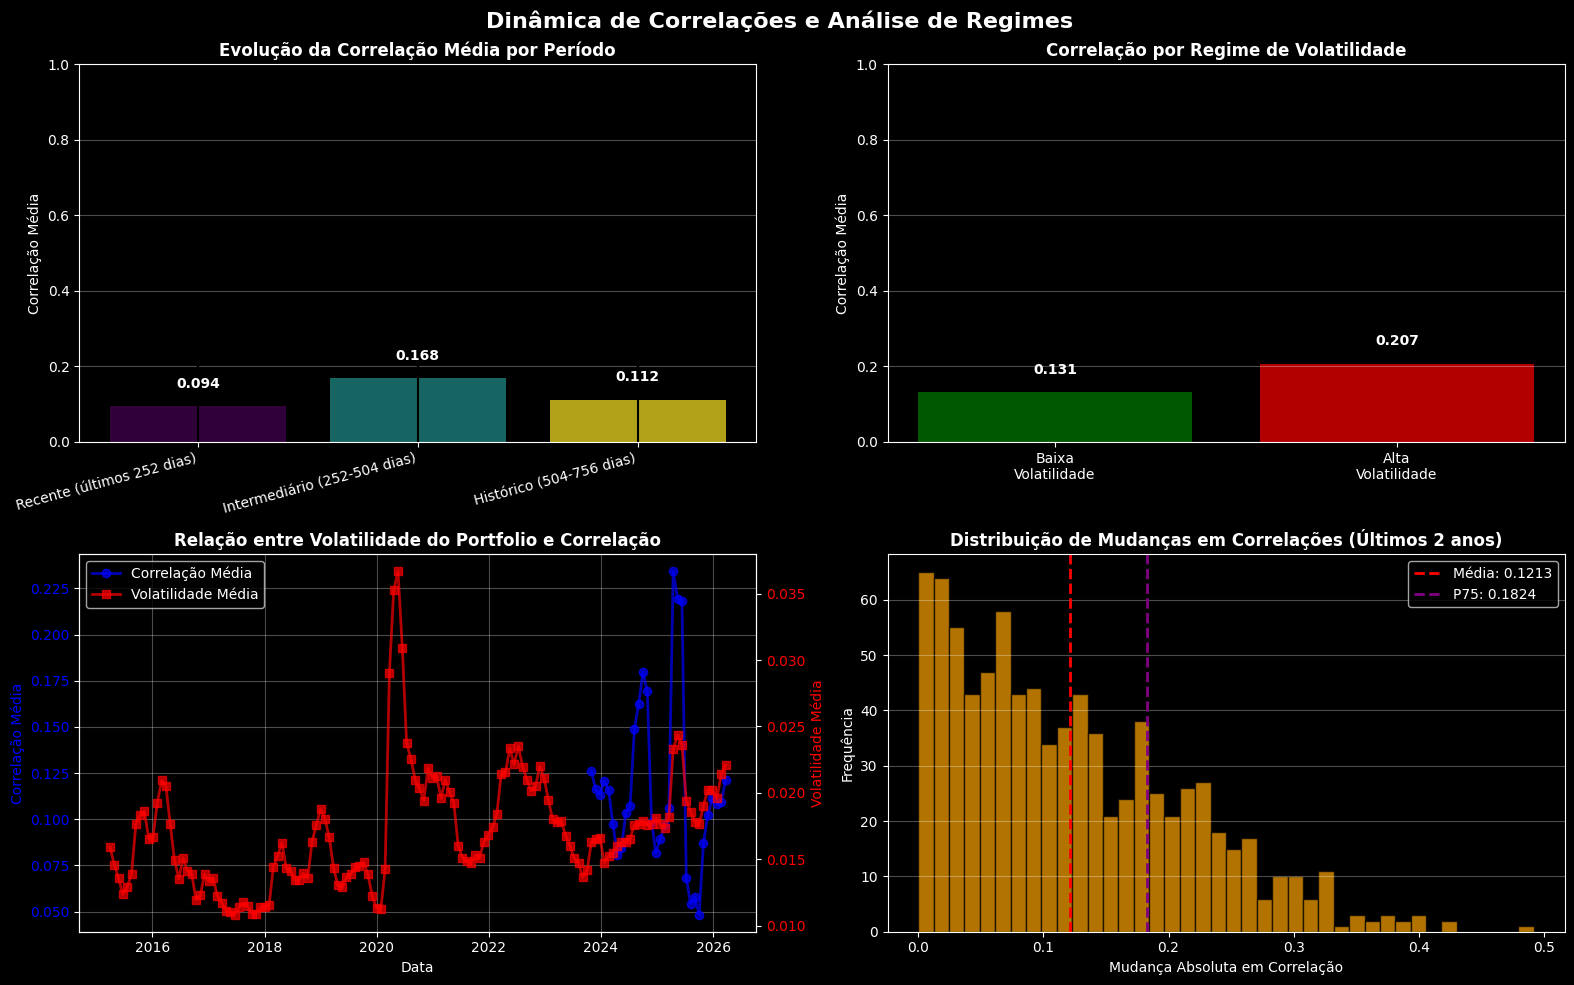


✓ Visualizações de Regimes e Dinâmica Criadas com Sucesso


In [15]:
# --- VISUALIZAÇÕES: Dinâmica de Correlações e Regimes ---

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Dinâmica de Correlações e Análise de Regimes', fontsize=16, fontweight='bold')

# Plot 1: Correlação por Período
ax1 = axes[0, 0]
period_names = list(period_analysis.keys())
period_means = [period_analysis[p]['mean'] for p in period_names]
period_stds = [period_analysis[p]['std'] for p in period_names]
colors_period = plt.cm.viridis(np.linspace(0, 1, len(period_names)))
bars1 = ax1.bar(range(len(period_names)), period_means, color=colors_period, alpha=0.7, yerr=period_stds, capsize=5)
ax1.set_xticks(range(len(period_names)))
ax1.set_xticklabels(period_names, rotation=15, ha='right')
ax1.set_ylabel('Correlação Média')
ax1.set_title('Evolução da Correlação Média por Período', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1)
for i, (bar, val) in enumerate(zip(bars1, period_means)):
    ax1.text(i, val + 0.05, f'{val:.3f}', ha='center', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Correlação em Regimes (Alta vs Baixa Volatilidade)
ax2 = axes[0, 1]
regime_labels = ['Baixa\nVolatilidade', 'Alta\nVolatilidade']
regime_corrs = []
if len(low_vol_data) > 10:
    regime_corrs.append(low_vol_mean)
if len(high_vol_data) > 10:
    regime_corrs.append(high_vol_mean)

if regime_corrs:
    colors_regime = ['green', 'red'][:len(regime_corrs)]
    bars2 = ax2.bar(regime_labels[:len(regime_corrs)], regime_corrs, color=colors_regime, alpha=0.7)
    ax2.set_ylabel('Correlação Média')
    ax2.set_title('Correlação por Regime de Volatilidade', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1)
    for bar, val in zip(bars2, regime_corrs):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.3f}', ha='center', fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Volatilidade do Portfolio vs Correlação
ax3 = axes[1, 0]
# Recalcular para plot
window = 63  # 3 meses
corr_by_window = []
vol_by_window = []
dates_by_window = []

for i in range(window, len(clean_ret_log), 20):
    window_ret = clean_ret_log.iloc[i-window:i]
    window_corr = window_ret.corr()
    corr_mean = window_corr.values[np.triu_indices_from(window_corr.values, k=1)].mean()
    vol_mean = window_ret.std().mean()
    
    corr_by_window.append(corr_mean)
    vol_by_window.append(vol_mean)
    dates_by_window.append(clean_ret_log.index[i])

ax3_twin = ax3.twinx()
line1 = ax3.plot(dates_by_window, corr_by_window, color='blue', linewidth=2, marker='o', label='Correlação Média', alpha=0.7)
line2 = ax3_twin.plot(dates_by_window, vol_by_window, color='red', linewidth=2, marker='s', label='Volatilidade Média', alpha=0.7)
ax3.set_xlabel('Data')
ax3.set_ylabel('Correlação Média', color='blue')
ax3_twin.set_ylabel('Volatilidade Média', color='red')
ax3.set_title('Relação entre Volatilidade do Portfolio e Correlação', fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='blue')
ax3_twin.tick_params(axis='y', labelcolor='red')
ax3.grid(True, alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='upper left')

# Plot 4: Distribuição de Mudanças em Correlações
ax4 = axes[1, 1]
ax4.hist(corr_changes_upper, bins=40, color='orange', alpha=0.7, edgecolor='black')
ax4.axvline(corr_changes_upper.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {corr_changes_upper.mean():.4f}')
ax4.axvline(np.percentile(corr_changes_upper, 75), color='purple', linestyle='--', linewidth=2, label=f'P75: {np.percentile(corr_changes_upper, 75):.4f}')
ax4.set_xlabel('Mudança Absoluta em Correlação')
ax4.set_ylabel('Frequência')
ax4.set_title('Distribuição de Mudanças em Correlações (Últimos 2 anos)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Visualizações de Regimes e Dinâmica Criadas com Sucesso")

In [16]:
from datetime import datetime

print("\n-> Compilando resultados no Dataset e salvando no CSV...")

# 1. Resgate seguro das variáveis (caso algum regime não tenha ocorrido na rodada)
alta_vol = high_vol_mean if 'high_vol_mean' in locals() else None
baixa_vol = low_vol_mean if 'low_vol_mean' in locals() else None
aumento_corr = correlation_increase if 'correlation_increase' in locals() else None
contagio = peak_contagion if 'peak_contagion' in locals() else None
mudanca_media_corr = corr_changes_upper.mean() if 'corr_changes_upper' in locals() else None

# Resgatando a correlação do período mais recente do seu dicionário
corr_recente = None
if 'period_analysis' in locals() and 'Recente (últimos 252 dias)' in period_analysis:
    corr_recente = period_analysis['Recente (últimos 252 dias)']['mean']

# 2. Empacotando TUDO em uma única linha de dados (Dicionário)
log_data = {
    'Timestamp_Execucao': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    
    # Métricas do Backtest (Código 1)
    'Capital_Final_RS': round(capital_final, 2),
    'Lucro_Total_RS': round(lucro_total_rs, 2),
    'Lucro_Total_Pct': round(lucro_total_pct, 4),
    'Max_Drawdown_Pct': round(max_drawdown, 4),
    'Media_Semanal_Pct': round(media_retorno, 4),
    'Mediana_Semanal_Pct': round(mediana_retorno, 4),
    
    # Métricas de Correlação e Regimes (Código 2)
    'Corr_Recente_252d': round(corr_recente, 4) if corr_recente else None,
    'Corr_Baixa_Vol': round(baixa_vol, 4) if baixa_vol else None,
    'Corr_Alta_Vol': round(alta_vol, 4) if alta_vol else None,
    'Aumento_Corr_Crise_Pct': round(aumento_corr, 2) if aumento_corr else None,
    'Pico_Contagio_Extremo': round(contagio, 4) if contagio else None,
    'Instabilidade_Corr_Media': round(mudanca_media_corr, 4) if mudanca_media_corr else None
}

# 3. Transforma o dicionário num DataFrame de uma linha
df_log = pd.DataFrame([log_data])

# 4. Lógica de Persistência no CSV (Cria se não existe, anexa se já existe)
pasta_destino = r'Finanças + Python\Base de Dados Finanças'
arquivo_csv = 'dataset_tracker_completo.csv'

if os.path.exists(arquivo_csv):
    # O arquivo já existe: Anexa a nova linha sem repetir o cabeçalho
    df_log.to_csv(arquivo_csv, mode='a', header=False, index=False, encoding='utf-8')
    print(f"✓ Rodada anexada com sucesso ao '{arquivo_csv}'.")
else:
    # Primeira rodada: Cria o arquivo com o cabeçalho
    df_log.to_csv(arquivo_csv, mode='w', header=True, index=False, encoding='utf-8')
    print(f"✓ Arquivo '{arquivo_csv}' criado!")

print("\n--- Histórico Completo de Simulações (Dataset) ---")

df_completo = pd.read_csv(arquivo_csv)
pd.set_option('display.max_rows', None)
display(df_completo)
pd.reset_option('display.max_rows')


-> Compilando resultados no Dataset e salvando no CSV...
✓ Rodada anexada com sucesso ao 'dataset_tracker_completo.csv'.

--- Histórico Completo de Simulações (Dataset) ---


,Timestamp_Execucao,Capital_Final_RS,Lucro_Total_RS,Lucro_Total_Pct,Max_Drawdown_Pct,Media_Semanal_Pct,Mediana_Semanal_Pct,Corr_Recente_252d,Corr_Baixa_Vol,Corr_Alta_Vol,Aumento_Corr_Crise_Pct,Pico_Contagio_Extremo,Instabilidade_Corr_Media
0,2026-03-12 15:09:13,142726.27,42726.27,0.4273,-0.0284,0.0036,0.0029,0.1432,0.1327,0.2141,61.30,NaN,0.1097
1,2026-03-12 15:11:06,150795.62,50795.62,0.5080,-0.0370,0.0042,0.0021,0.1432,0.1327,0.2141,61.30,NaN,0.1097
2,2026-03-12 15:21:22,135584.75,35584.75,0.3558,-0.0298,0.0031,0.0016,0.1432,0.1327,0.2141,61.30,NaN,0.1097
3,2026-03-12 15:27:02,145174.61,45174.61,0.4517,-0.0458,0.0038,0.0042,0.1432,0.1327,0.2141,61.30,NaN,0.1097
4,2026-03-12 15:32:59,129629.02,29629.02,0.2963,-0.1561,0.0029,0.0038,0.1432,0.1327,0.2141,61.30,NaN,0.1097
5,2026-03-12 15:34:01,159684.57,59684.57,0.5968,-0.0678,0.0048,0.0051,0.1432,0.1327,0.2141,61.30,NaN,0.1097
6,2026-03-12 17:40:17,127470.64,27470.64,0.2747,-0.1095,0.0025,0.0038,0.1432,0.1327,0.2141,61.30,NaN,0.1097
7,2026-03-13 11:42:33,168331.09,68331.09,0.6833,-0.0656,0.0054,0.0065,0.1432,0.1327,0.2141,61.30,NaN,0.1097
8,2026-03-13 11:53:48,134994.51,34994.51,0.3499,-0.0993,0.0031,0.0028,0.1432,0.1327,0.2141,61.30,NaN,0.1097
9,2026-03-13 11:55:00,135453.69,35453.69,0.3545,-0.0787,0.0032,0.0043,0.1432,0.1327,0.2141,61.30,NaN,0.1097


In [17]:
%pip install backtrader

Note: you may need to restart the kernel to use updated packages.
